# 토스 광고 CTR 분석 — 논문 제출용 실행 노트북

## 분석 개요
- **데이터**: Dacon 토스 CTR 예측 대회 (train/test Parquet)
- **연구 목적**: 사용자 특성(연령·성별)·시간대·광고 지면 환경이 클릭률(CTR)에 미치는 영향을 통계적으로 검정하고, 머신러닝 모델로 재검증한다.
- **실행 순서**: 셀 [0] → [12] 순서대로 실행 (셀 건너뜀 금지)
- **데이터 경로**: 프로젝트 루트의 `data/` 폴더 기준으로 자동 탐색

| 셀 번호 | 내용 |
|---------|------|
| [0] | 라이브러리 임포트 & 환경 설정 |
| [1] | 경로 설정 & 데이터 로드 |
| [1-H] | 공통 헬퍼 함수 & 상수 |
| [2] | 파생 변수 생성 |
| [3] | 타깃 변수 분포 분석 |
| [4] | RQ1 — 연령대별 CTR |
| [5] | RQ2 — 시간대별 클릭 패턴 |
| [6] | RQ3 — 광고 노출 환경 |
| [7] | 피처 엔지니어링 & 전처리 |
| [8] | RQ4 — 모델 학습 비교 |
| [9] | Ablation Study |
| [10] | SHAP 해석 |
| [11] | 추론 & 제출 파일 생성 |
| [12] | 논문용 최종 요약 |


In [1]:
# ============================================================
# [0] 라이브러리 임포트 및 공통 설정
# ------------------------------------------------------------
# 목적:
#   분석 전반에 걸쳐 사용할 패키지를 한 번에 불러오고,
#   OS 환경에 맞는 한글 폰트와 플롯 스타일을 자동 설정한다.
#   실험 재현성을 위해 불필요한 경고 메시지를 억제한다.
# ============================================================

import os, platform, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# ConvergenceWarning 등 결과에 영향 없는 경고 차단
warnings.filterwarnings('ignore')

# ── 한글 폰트 자동 설정 ────────────────────────────────────
# matplotlib 기본 폰트는 한글 미지원 → 글자 깨짐 방지용.
# OS별 우선순위 폰트 목록에서 설치된 것 중 첫 번째를 선택.
_avail_fonts = [f.name for f in fm.fontManager.ttflist]
_font_priority = {
    'Windows': ['Malgun Gothic', 'NanumGothic'],                   # Windows: 맑은 고딕
    'Darwin':  ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic'],  # macOS
    'Linux':   ['NanumGothic', 'UnDotum', 'DejaVu Sans'],              # Linux / Colab
}
_system = platform.system()
for _f in _font_priority.get(_system, ['DejaVu Sans']):
    if _f in _avail_fonts:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지
plt.style.use('seaborn-v0_8-whitegrid')      # 논문용 화이트그리드 스타일
sns.set_palette("husl")                       # 색상 대비가 명확한 husl 팔레트

# ── GPU / CPU 디바이스 확인 ────────────────────────────────
# 본 노트북은 scikit-learn / XGBoost 중심이므로 GPU 직접 사용은 없음.
# CUDA 가용 여부를 환경 정보로 기록해 두기 위해 포함.
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device}')


# ============================================================


디바이스: cpu


In [2]:
# ============================================================
# [1] 경로 설정 및 데이터 로드
# ------------------------------------------------------------
# 목적:
#   Dacon 토스 CTR 예측 대회 원본 데이터를 메모리 효율적으로 로드한다.
#
# 핵심 설계:
#   • train.parquet 는 수백만 행 → Reservoir Sampling 으로
#     20만 행(train_sample.parquet)을 균일 추출해 저장.
#   • 이미 샘플 파일이 있으면 재생성 없이 바로 로드 (실행 시간 단축).
#   • test.parquet 는 배치(100K 행) 단위로 읽어 OOM 방지.
#
# 주요 변수:
#   train  ─ 분석·학습용 샘플 DataFrame  (20만 행)
#   test   ─ 최종 예측용 테스트 DataFrame
#   sample ─ 제출 양식 확인용 sample_submission
# ============================================================

# ── 전역 상수 ──────────────────────────────────────────────
RANDOM_STATE = 42        # 모든 난수 시드 고정 → 재현성 보장
SAMPLE_SIZE  = 200_000   # 분석에 사용할 최대 샘플 수
BATCH_SIZE   = 100_000   # Parquet 배치 읽기 크기 (메모리 절약)

# ── 데이터 폴더 자동 탐색 ──────────────────────────────────
# 현재 또는 상위 디렉터리에서 'data/' 폴더를 찾아 BASE_DIR 설정.
# → Colab / 로컬 환경 모두 동일 코드로 실행 가능.
for _root in (Path.cwd(), Path.cwd().parent):
    if (_root / 'data').exists():
        BASE_DIR = _root
        break
else:
    BASE_DIR = Path.cwd()

TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'
TRAIN_PATH        = BASE_DIR / 'data' / 'train.parquet'
TEST_PATH         = BASE_DIR / 'data' / 'test.parquet'

# ── Reservoir Sampling: train_sample 생성 (없을 때만) ─────
# 전체 파일을 한 번에 읽지 않고 배치 단위로 처리.
# 각 배치에 균일 랜덤 키(_rand_key)를 부여 후 상위 N개 선택
# → 전체 행에 대해 균일한 무작위 샘플 보장.
if not TRAIN_SAMPLE_PATH.exists():
    import pyarrow.parquet as pq
    if not TRAIN_PATH.exists():
        raise FileNotFoundError(f'train.parquet 없음: {TRAIN_PATH}')
    print(f'[생성] train_sample → {TRAIN_SAMPLE_PATH}')
    rng  = np.random.default_rng(RANDOM_STATE)
    pf   = pq.ParquetFile(str(TRAIN_PATH))
    reservoir, total_rows = None, 0
    for batch in pf.iter_batches(batch_size=BATCH_SIZE):
        chunk = batch.to_pandas()
        total_rows += len(chunk)
        chunk['_rand_key'] = rng.random(len(chunk))   # 균일 랜덤 키 부여
        reservoir = chunk if reservoir is None else pd.concat([reservoir, chunk], ignore_index=True)
        # 레저버가 목표 크기의 3배를 초과하면 상위 N개만 유지 (메모리 절약)
        if len(reservoir) > SAMPLE_SIZE * 3:
            reservoir = reservoir.nlargest(SAMPLE_SIZE, '_rand_key')
    n = min(SAMPLE_SIZE, len(reservoir))
    train_sample = (reservoir.nlargest(n, '_rand_key')
                              .drop(columns=['_rand_key'])               # 임시 키 제거
                              .sample(frac=1.0, random_state=RANDOM_STATE)  # 행 순서 셔플
                              .reset_index(drop=True))
    TRAIN_SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    train_sample.to_parquet(TRAIN_SAMPLE_PATH, index=False)
    print(f'[완료] {n:,}행 저장 (전체 {total_rows:,}행 중)')

# clicked 컬럼: parquet 저장 시 bool로 저장될 수 있으므로 int 강제 변환
train = pd.read_parquet(TRAIN_SAMPLE_PATH)
train['clicked'] = train['clicked'].astype(int)

# ── sample_submission 로드 ─────────────────────────────────
# 가능한 경로를 순서대로 시도 (대회 폴더 구조 차이 대응)
_sample_path = next(
    (p for p in [BASE_DIR / 'data' / 'sample_submission.csv',
                 Path('static_document_dataset/sample_submission.csv')]
     if p.exists()), None
)
sample = pd.read_csv(_sample_path) if _sample_path else None

# ── test 배치 로드 함수 ────────────────────────────────────
# test.parquet 가 대용량일 경우 배치로 분할 읽기 → 메모리 초과 방지
def load_parquet_batches(path: Path, batch_size: int = 100_000) -> pd.DataFrame:
    import pyarrow.parquet as pq
    return pd.concat(
        [b.to_pandas() for b in pq.ParquetFile(str(path)).iter_batches(batch_size=batch_size)],
        ignore_index=True
    )

test = load_parquet_batches(TEST_PATH) if TEST_PATH.exists() else None

print(f'train shape : {train.shape}')
print(f'CTR         : {train["clicked"].mean():.4f}')
print(f'columns     : {list(train.columns[:10])} ...')


# ============================================================


train shape : (200000, 119)
CTR         : 0.0190
columns     : ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4'] ...


In [ ]:
# ============================================================
# [1-Helper] 공통 헬퍼 함수 및 상수 정의
# ------------------------------------------------------------
# 목적:
#   RQ1 ~ RQ3 통계 검정에서 반복 사용되는 로직을 함수로 추상화해
#   코드 중복을 줄이고 결과의 일관성을 확보한다.
#
# 제공 함수:
#   print_section(title)    ─ 분석 단계 구분선 출력
#   run_anova_eta(df, ...)  ─ One-Way ANOVA + eta² 효과 크기
#   ctr_desc(df, ...)       ─ 그룹별 CTR 기술통계 + 95% 신뢰구간
# ============================================================

from scipy.stats import f_oneway

DAY_NAMES   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']  # 요일 레이블 (0=월요일)
PRINT_WIDTH = 65                                            # 콘솔 구분선 너비


def print_section(title):
    """분석 단계 구분선을 출력해 콘솔 로그 가독성을 높인다."""
    print('\n' + '='*PRINT_WIDTH)
    print(title)
    print('='*PRINT_WIDTH)


def run_anova_eta(df, group_col, target='clicked', groups=None):
    """
    One-Way ANOVA 및 eta-squared(eta2) 효과 크기를 계산한다.

    ■ ANOVA
      H0: 모든 그룹의 모집단 평균이 동일하다.
      H1: 적어도 하나의 그룹 평균이 다르다.
      → F 통계량이 크고 p < 0.05 이면 H0 기각.

    ■ eta2 (효과 크기)
      eta2 = SS_between / SS_total
      해석 기준 (Cohen, 1988):
        - eta2 < 0.06            → small  (작은 효과)
        - 0.06 <= eta2 < 0.14   → medium (중간 효과)
        - eta2 >= 0.14           → large  (큰 효과)

    Parameters
    ----------
    df        : pd.DataFrame
    group_col : str   — 그룹 구분 열 (예: 'age_group')
    target    : str   — 종속변수 열 (기본: 'clicked')
    groups    : list  — 분석할 그룹 값; None 이면 자동 추출

    Returns
    -------
    F, p, eta2 : float
    """
    if groups is None:
        groups = sorted(df[group_col].dropna().unique())
    samples = [df[df[group_col] == g][target].values for g in groups]
    samples = [s for s in samples if len(s) > 0]   # 빈 그룹 제거
    F, p = f_oneway(*samples)

    grand      = df[target].mean()
    ss_total   = ((df[target] - grand) ** 2).sum()
    ss_between = sum(len(s) * (s.mean() - grand) ** 2 for s in samples)
    eta2       = ss_between / ss_total if ss_total > 0 else 0.0

    return F, p, eta2


def ctr_desc(df, group_col, target='clicked'):
    """
    그룹별 CTR 기술통계 및 95% 신뢰구간을 반환한다.

    ■ 95% CI 계산 방법
      CI = 1.96 * (sigma / sqrt(n))
      클릭(0/1 이항)에 중심극한정리 기반 정규 근사 적용.
      n >= 30 이면 근사가 충분히 성립한다.

    Parameters
    ----------
    df        : pd.DataFrame
    group_col : str — 그룹 구분 열
    target    : str — 종속변수 열 (기본: 'clicked')

    Returns
    -------
    pd.DataFrame — 열: Sample_Count, Click_Rate, Std_Dev, CI_95
    """
    out = df.groupby(group_col)[target].agg(
        Sample_Count='count',
        Click_Rate='mean',
        Std_Dev='std'
    ).round(4)
    # 1.96 * 표준오차 = 95% 신뢰구간 반폭(half-width)
    out['CI_95'] = 1.96 * (out['Std_Dev'] / np.sqrt(out['Sample_Count'].replace(0, np.nan)))
    out['CI_95'] = out['CI_95'].fillna(0)
    return out


# ============================================================


In [3]:
# ============================================================
# [2] 파생 변수 생성 (1회만 실행)
# ------------------------------------------------------------
# 목적:
#   원시 데이터에서 통계 분석 및 ML 모델에 유용한
#   파생 피처(derived features)를 생성한다.
#
# 생성 피처 분류:
#   (A) 시퀀스 특성     ─ 사용자 행동 다양성·반복성
#   (B) 시간 파생       ─ 4구간 시간대, 주말·피크 이진 플래그
#   (C) 교호작용 항     ─ 연령 x 성별 세그먼트 조합
#   (D) 히스토리 집계   ─ history_a/b 합계·평균·최대 (차원 축소)
#   (E) 인벤토리 인코딩 ─ 지면별 평균 CTR (Target Encoding)
# ============================================================

df = train.copy()   # 원본 보존을 위해 복사본에서 작업

# ── (전처리) 타입 보정 ─────────────────────────────────────
# 일부 컬럼이 문자열로 저장된 경우 강제 수치 변환;
# 변환 실패(errors='coerce') 시 NaN → -1 로 채워 이상치 구분
df['hour']        = pd.to_numeric(df['hour'],        errors='coerce').fillna(-1).astype(int)
df['day_of_week'] = pd.to_numeric(df['day_of_week'], errors='coerce').fillna(-1).astype(int)

# ── (A) 시퀀스 파생 피처 ──────────────────────────────────
# seq: 사용자 최근 소비 콘텐츠 ID 시퀀스 (쉼표 구분 문자열)
df['seq_length']      = df['seq'].astype(str).str.split(',').str.len()
df['unique_items']    = df['seq'].astype(str).apply(lambda s: len(set(s.split(','))))
df['diversity_ratio'] = (df['unique_items'] / df['seq_length'].replace(0, np.nan)).fillna(0)  # 다양성 비율 (0~1)
df['repeat_ratio']    = 1 - df['diversity_ratio']                                               # 반복 소비 비율

# ── (B) 시간 파생 피처 ────────────────────────────────────
# 24시간을 4구간으로 분할 → RQ2 시간대 분석에 활용
df['hour_period'] = pd.cut(
    df['hour'], bins=[-1, 5, 11, 17, 23],
    labels=['심야(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)']
)
# 이진 피처: 선형 모델도 비선형 시간 패턴을 학습할 수 있게 보조
df['is_weekend']   = df['day_of_week'].isin([5, 6, 7]).astype(int)   # 1 = 주말
df['is_peak_hour'] = df['hour'].between(12, 18).astype(int)           # 1 = 오후 피크

# ── (C) 사용자 교호작용 항 ────────────────────────────────
# 연령대·성별을 조합한 세분화 세그먼트 (예: '20_M', '30_F')
# 단순 주효과로는 포착 못하는 교호작용 패턴 분석에 활용
df['age_gender_interaction'] = df['age_group'].astype(str) + '_' + df['gender'].astype(str)

# ── (D) 히스토리 집계 피처 ────────────────────────────────
# history_a_*, history_b_*: 사용자 과거 클릭·조회 이력 컬럼 군.
# 개별 컬럼 수가 많아 차원 축소 목적으로 합계·평균·최대만 추출.
for prefix in ('history_a', 'history_b'):
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    if cols:
        df[f'{prefix}_sum']  = df[cols].fillna(0).sum(axis=1)    # 전체 이력 합계
        df[f'{prefix}_mean'] = df[cols].fillna(0).mean(axis=1)   # 평균 이력 강도
        df[f'{prefix}_max']  = df[cols].fillna(0).max(axis=1)    # 최대 단일 이력

# history_a / history_b 비율: 두 이력 유형의 상대적 강도
# 분모에 1e-6 추가 → 0 나눗셈 방지 (Laplace smoothing 원리)
df['history_ab_ratio'] = (
    df.get('history_a_sum', 0) + 1e-6
) / (df.get('history_b_sum', 0) + 1e-6)

# ── (E) 인벤토리 Target Encoding ──────────────────────────
# inventory_id(광고 지면)별 평균 CTR로 수치 인코딩.
# 카디널리티 높은 범주형 변수를 효율적으로 수치화하는 기법.
# ※ 주의: 실제 운영에서는 train 기준으로만 인코딩 맵 생성 필수
#         (val/test 정보 누수 방지)
df['inv_ctr_encoded'] = df['inventory_id'].map(
    df.groupby('inventory_id')['clicked'].mean()
)

# 전체 CTR — 이후 시각화에서 기준선(reference line)으로 사용
GLOBAL_CTR = df['clicked'].mean()

print(f'\n데이터: {len(df):,}샘플 / {df["clicked"].sum():,}클릭')
print(f'전체 CTR: {GLOBAL_CTR:.4f} ({GLOBAL_CTR*100:.2f}%)')
print(f'클래스 불균형: {(1-GLOBAL_CTR)/GLOBAL_CTR:.1f}:1')
print('파생 변수 생성 완료')


# ============================================================



데이터: 200,000샘플 / 3,804클릭
전체 CTR: 0.0190 (1.90%)
클래스 불균형: 51.6:1
파생 변수 생성 완료



전체 클릭률: 0.0190 (1.90%)
총 클릭 수 : 3,804 / 200,000
불균형 비율: 51.6:1 (비클릭:클릭)


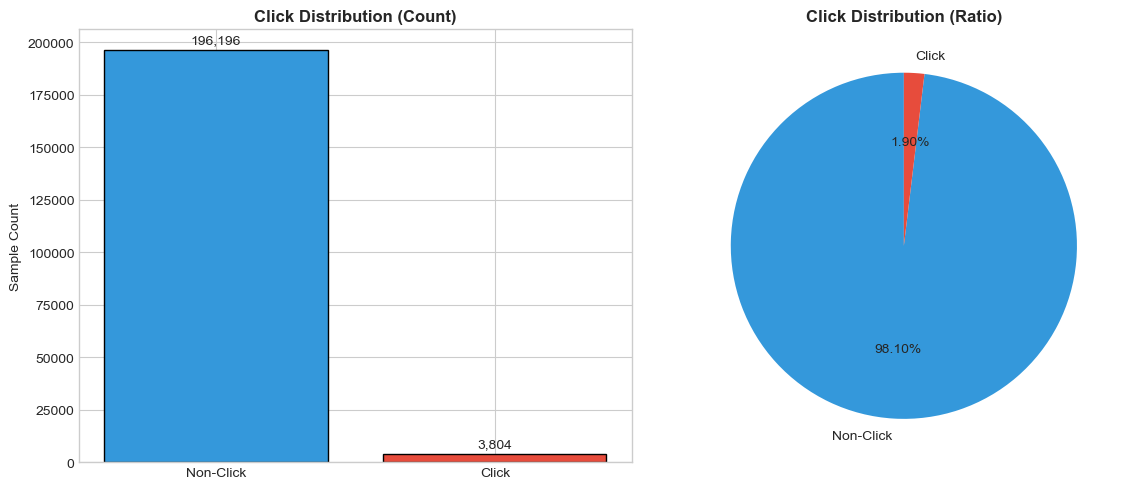

In [ ]:
# ============================================================
# [3] 타깃 변수 분포 분석 (EDA)
# ------------------------------------------------------------
# 목적:
#   종속변수 clicked (0/1) 의 분포를 확인하여
#   클래스 불균형(class imbalance) 수준을 정량적으로 파악한다.
#
# 클래스 불균형이 심할수록:
#   - 정확도(Accuracy)는 misleading → AUC·AP 를 주 평가 지표로 사용
#   - 모델에 class_weight='balanced' / scale_pos_weight 설정 필요
# ============================================================

click_counts = df['clicked'].value_counts().sort_index()
click_rate   = df['clicked'].mean()

print(f'\n전체 클릭률: {click_rate:.4f} ({click_rate*100:.2f}%)')
print(f'총 클릭 수 : {df["clicked"].sum():,} / {len(df):,}')
print(f'불균형 비율: {(1-click_rate)/click_rate:.1f}:1 (비클릭:클릭)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 왼쪽: 막대 그래프 (절대 빈도) ──────────────────────────
# 샘플 수 차이를 시각화해 불균형의 심각도를 직관적으로 전달
bars = axes[0].bar(['Non-Click', 'Click'], click_counts.values,
                   color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Click Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Sample Count')
for bar, val in zip(bars, click_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(click_counts)*0.01,
                 f'{val:,}', ha='center', va='bottom')

# ── 오른쪽: 파이 차트 (상대 비율) ───────────────────────────
# 퍼센트로 불균형 비율을 한눈에 제시 (논문 Figure 삽입용)
axes[1].pie(click_counts.values, labels=['Non-Click', 'Click'],
            colors=['#3498db', '#e74c3c'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Click Distribution (Ratio)', fontweight='bold')

plt.tight_layout()
plt.show()


# ============================================================



RQ1. 연령대별 클릭률 분석
           Sample_Count  Click_Count  Click_Rate  Std_Dev  CI_95_Lower  CI_95_Upper
age_group                                                                          
1.0                 526           47      0.0894   0.2855       0.0650       0.1138
2.0                6728          160      0.0238   0.1524       0.0202       0.0274
3.0                9139          198      0.0217   0.1456       0.0187       0.0247
4.0               10290          179      0.0174   0.1307       0.0149       0.0199
5.0               11137          192      0.0172   0.1302       0.0148       0.0196
6.0               43375          669      0.0154   0.1232       0.0142       0.0166
7.0               69023         1173      0.0170   0.1293       0.0160       0.0180
8.0               49455         1175      0.0238   0.1523       0.0225       0.0251

[ANOVA]          F=37.1173, p=0.000000 ***
[Kruskal-Wallis] H=259.4922, p=0.000000 ***
[Effect size]    eta2=0.001296 (small)

[Tukey HSD]
Mu

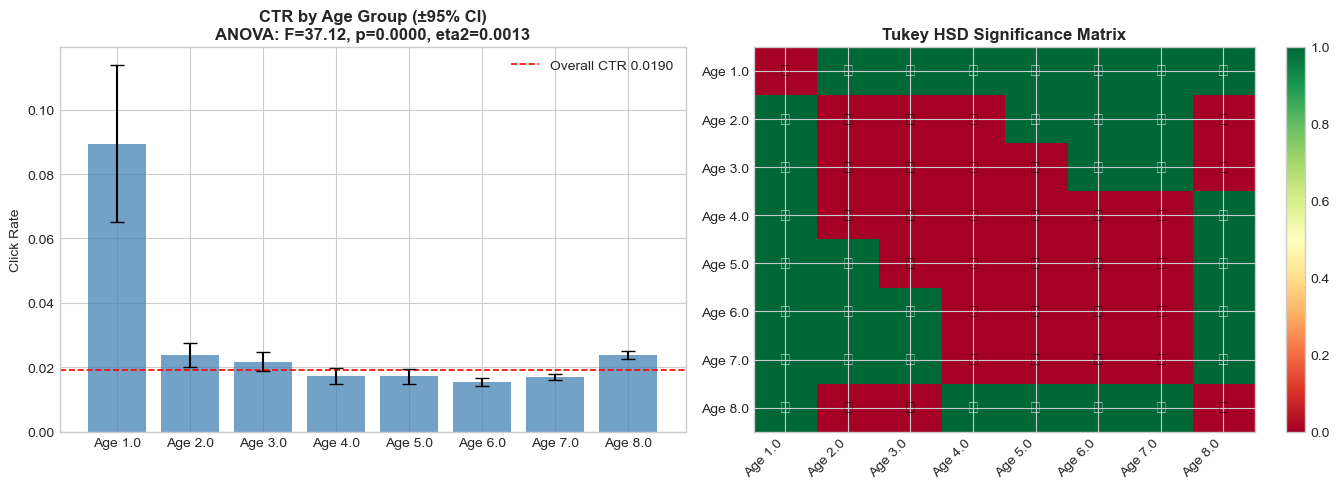

In [ ]:
# ============================================================
# [4] RQ1 — 연령대별 CTR 분석 (통계 검정 + 시각화)
# ------------------------------------------------------------
# 연구 질문:
#   '연령대에 따라 광고 클릭률(CTR)에 유의미한 차이가 있는가?'
#
# 분석 전략:
#   1) 기술통계   ─ 연령대별 CTR 평균·표준편차·95% CI
#   2) ANOVA      ─ One-Way F-검정 (H0: 모든 연령대 CTR 평균 동일)
#                    + eta2 효과 크기 (집단 간 분산 설명력)
#   3) Kruskal-Wallis ─ 비모수 검정으로 ANOVA 결과 강건성 확인
#                        (0/1 이항 변수는 정규성 가정이 불완전)
#   4) Tukey HSD  ─ 사후 검정: 어느 연령 쌍이 다른지 특정
#   5) Chi2       ─ 성별 × 클릭 독립성 검정 + Cramer's V
# ============================================================

from scipy.stats import f_oneway, kruskal, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print_section('RQ1. 연령대별 클릭률 분석')

# 분석 대상 연령 그룹 목록 (결측 제외 후 오름차순)
age_groups = sorted(df['age_group'].dropna().unique())

# ── 1) 기술통계 ───────────────────────────────────────────
age_desc = ctr_desc(df, 'age_group')
age_desc['CI_95_Lower'] = age_desc['Click_Rate'] - age_desc['CI_95']
age_desc['CI_95_Upper'] = age_desc['Click_Rate'] + age_desc['CI_95']
print(age_desc.round(4).to_string())

# ── 2) One-Way ANOVA + eta2 ────────────────────────────────
F_age, p_anova_age, eta_sq_age = run_anova_eta(df, 'age_group')

# ── 3) Kruskal-Wallis (비모수 강건성 검증) ─────────────────
# ANOVA 와 같은 방향의 유의성이면 결과 신뢰도 상승
age_samples = [df[df['age_group'] == ag]['clicked'].values for ag in age_groups]
H_age, p_kruskal_age = kruskal(*age_samples)

print(f'\n[ANOVA]          F={F_age:.4f}, p={p_anova_age:.6f} {"***" if p_anova_age<0.001 else ""}')
print(f'[Kruskal-Wallis] H={H_age:.4f}, p={p_kruskal_age:.6f} {"***" if p_kruskal_age<0.001 else ""}')
print(f'[Effect size]    eta2={eta_sq_age:.6f} '
      f'({"large" if eta_sq_age>=0.14 else "medium" if eta_sq_age>=0.06 else "small"})')

# ── 4) Tukey HSD 사후 검정 ────────────────────────────────
# ANOVA 유의 시 어느 연령 쌍(pair)이 다른지 다중 비교 수행.
# Tukey HSD 는 familywise error rate(FWER)를 alpha 수준으로 통제.
_mask     = df['age_group'].notna()
tukey_age = pairwise_tukeyhsd(
    endog=df.loc[_mask, 'clicked'], groups=df.loc[_mask, 'age_group'], alpha=0.05
)
print('\n[Tukey HSD]')
print(tukey_age.summary())

# ── 5) 성별 Chi2 + Cramer's V ─────────────────────────────
# 성별과 클릭 여부의 독립성 검정.
# Cramer's V: 카이제곱 기반 효과 크기 (0~1; 1 = 완전 연관)
ct_gender = pd.crosstab(df['gender'], df['clicked'])
chi2_g, p_chi2_g, _, _ = chi2_contingency(ct_gender)
cramers_v = np.sqrt(chi2_g / (ct_gender.values.sum() * (min(ct_gender.shape)-1)))
print(f'\n[Gender Chi2] chi2={chi2_g:.4f}, p={p_chi2_g:.6f}, Cramer\'s V={cramers_v:.4f}')

# ── 시각화 준비: Tukey 유의성 행렬 생성 ──────────────────
# 연령 쌍별 reject 여부를 n x n 행렬로 변환 → 히트맵 표시
n         = len(age_groups)
age_index = {str(v): i for i, v in enumerate(age_groups)}
sig_mat   = np.zeros((n, n))
for row in tukey_age.summary().data[1:]:
    g1, g2, *_, reject_raw = row
    reject = str(reject_raw).strip().lower() == 'true' if isinstance(reject_raw, str) else bool(reject_raw)
    i, j   = age_index.get(str(g1)), age_index.get(str(g2))
    if i is not None and j is not None:
        sig_mat[i, j] = sig_mat[j, i] = int(reject)  # 대칭 행렬 (1=유의)

ctrs  = age_desc['Click_Rate'].values
ci_lo = age_desc['CI_95_Lower'].values
ci_hi = age_desc['CI_95_Upper'].values
x_pos = range(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 왼쪽: CTR 막대 + 95% CI 에러바 ───────────────────────
# 빨간 점선 = 전체 평균 CTR (기준선)
axes[0].bar(x_pos, ctrs, color='steelblue', alpha=0.75, zorder=2)
axes[0].errorbar(x_pos, ctrs, yerr=[ctrs-ci_lo, ci_hi-ctrs],
                 fmt='none', color='black', capsize=5, zorder=3)
axes[0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {GLOBAL_CTR:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age {ag}' for ag in age_groups])
axes[0].set_title(f'CTR by Age Group (±95% CI)\nANOVA: F={F_age:.2f}, p={p_anova_age:.4f}, eta2={eta_sq_age:.4f}',
                  fontweight='bold')
axes[0].set_ylabel('Click Rate')
axes[0].legend()

# ── 오른쪽: Tukey HSD 유의성 히트맵 ──────────────────────
# 녹색(✓) = 두 연령대 간 유의한 CTR 차이 있음
# 적색(✗) = 차이 없음
im = axes[1].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(n)); axes[1].set_yticks(range(n))
axes[1].set_xticklabels([f'Age {ag}' for ag in age_groups], rotation=45, ha='right')
axes[1].set_yticklabels([f'Age {ag}' for ag in age_groups])
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, '✓' if sig_mat[i, j] else '✗',
                     ha='center', va='center',
                     color='white' if sig_mat[i, j] else 'black', fontsize=12)
axes[1].set_title('Tukey HSD Significance Matrix', fontweight='bold')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('RQ1_age_ctr.png', dpi=150, bbox_inches='tight')   # 논문 Figure용 고해상도 저장
plt.show()


# ============================================================



RQ2. 시간대별 클릭 패턴 분석
[Time Period CTR]
             Sample_Count  Click_Rate
hour_period                          
심야(0-5)             23769      0.0188
오전(6-11)            65281      0.0180
오후(12-17)           53251      0.0202
저녁(18-23)           57699      0.0192

[ANOVA 24h]  F=2.51, p=0.000078 ***
[ANOVA 4구간] F=2.61, p=0.049916 
[ANOVA 요일]  F=3.59,  p=0.001468 
[eta2 시간]   0.000289  [eta2 요일] 0.000108

[Tukey HSD - 시간 구간]
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
  심야(0-5)  오전(6-11)  -0.0007 0.8874 -0.0034 0.0019  False
  심야(0-5) 오후(12-17)   0.0015 0.5175 -0.0013 0.0042  False
  심야(0-5) 저녁(18-23)   0.0004  0.983 -0.0023 0.0031  False
 오전(6-11) 오후(12-17)   0.0022 0.0285  0.0002 0.0043   True
 오전(6-11) 저녁(18-23)   0.0011 0.4641 -0.0009 0.0031  False
오후(12-17) 저녁(18-23)  -0.0011 0.5576 -0.0032  0.001  False
------------------------------------------------

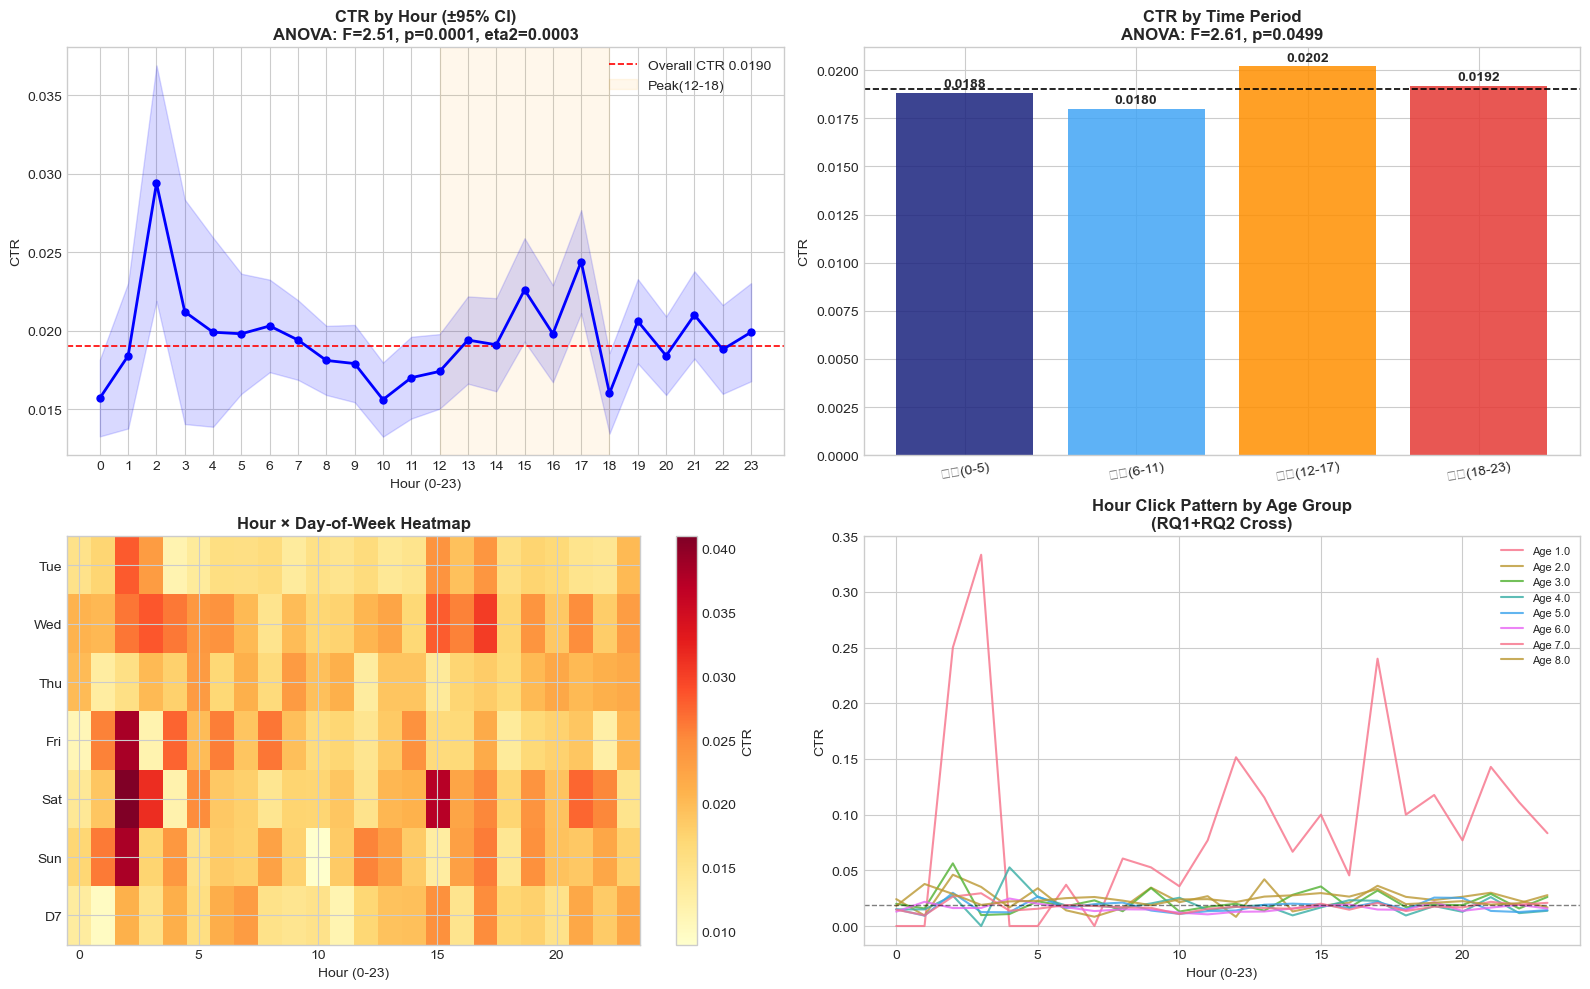

In [ ]:
# ============================================================
# [5] RQ2 — 시간대별 클릭 패턴 분석 (통계 검정 + 시각화)
# ------------------------------------------------------------
# 연구 질문:
#   '광고 노출 시간대에 따라 CTR 에 유의미한 차이가 있는가?'
#
# 분석 전략:
#   1) 기술통계   ─ 24시간 단위 / 4구간 / 요일별 CTR
#   2) ANOVA      ─ 시간(24) · 4구간 · 요일(7) 각각 검정
#   3) Tukey HSD  ─ 4구간 간 사후 비교 (어느 구간이 서로 다른지)
#   4) 시각화     ─ 시계열 선·4구간 막대·요일×시간 히트맵·연령 교차
# ============================================================

print_section('RQ2. 시간대별 클릭 패턴 분석')

# ── 1) 기술통계 ───────────────────────────────────────────
hour_desc   = ctr_desc(df, 'hour')        # 시(0~23)별 CTR
period_desc = ctr_desc(df, 'hour_period') # 4구간별 CTR
print('[Time Period CTR]')
print(period_desc.to_string())

# ── 2) ANOVA ─────────────────────────────────────────────
# 2-1. 24시간 ANOVA: 시간(0~23) → CTR 영향
F_hour, p_hour, eta_sq_hour = run_anova_eta(df, 'hour')

# 2-2. 4구간 ANOVA: 심야/오전/오후/저녁 → 해석 용이성 향상
F_period, p_period, _ = run_anova_eta(
    df, 'hour_period',
    groups=['심야(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)']
)

# 2-3. 요일 ANOVA: 주중/주말 등 요일별 패턴 검정
F_dow, p_dow, eta_sq_dow = run_anova_eta(df, 'day_of_week')

# ── 3) Tukey HSD (시간 구간 사후 비교) ───────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd
period_data  = df[['hour_period', 'clicked']].dropna()
tukey_period = pairwise_tukeyhsd(
    endog=period_data['clicked'], groups=period_data['hour_period'], alpha=0.05
)

print(f'\n[ANOVA 24h]   F={F_hour:.2f}, p={p_hour:.6f} {"***" if p_hour<0.001 else ""}')
print(f'[ANOVA 4구간] F={F_period:.2f}, p={p_period:.6f} {"***" if p_period<0.001 else ""}')
print(f'[ANOVA 요일]  F={F_dow:.2f},  p={p_dow:.6f} {"***" if p_dow<0.001 else ""}')
print(f'[eta2 시간]   {eta_sq_hour:.6f}  [eta2 요일] {eta_sq_dow:.6f}')
print('\n[Tukey HSD - 시간 구간]')
print(tukey_period.summary())

# ── 4) 시각화 (2×2 서브플롯) ─────────────────────────────
h_ctrs = hour_desc['Click_Rate'].values
h_ci   = hour_desc['CI_95'].values
hours  = list(range(24))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# [좌상] 시간별 CTR 선 그래프 + 95% CI 음영
# 오후 피크(12~18시)를 주황 음영으로 강조
axes[0, 0].plot(hours, h_ctrs, 'b-o', linewidth=2, markersize=5, zorder=3)
axes[0, 0].fill_between(hours, h_ctrs-h_ci, h_ctrs+h_ci, alpha=0.15, color='blue')
axes[0, 0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                   label=f'Overall CTR {GLOBAL_CTR:.4f}')
axes[0, 0].axvspan(12, 18, alpha=0.08, color='orange', label='Peak(12-18)')
axes[0, 0].set_title(f'CTR by Hour (±95% CI)\nANOVA: F={F_hour:.2f}, p={p_hour:.4f}, eta2={eta_sq_hour:.4f}',
                     fontweight='bold')
axes[0, 0].set_xlabel('Hour (0-23)'); axes[0, 0].set_ylabel('CTR')
axes[0, 0].legend(); axes[0, 0].set_xticks(hours)

# [우상] 4구간별 CTR 막대 (심야=남색, 오전=하늘, 오후=주황, 저녁=빨강)
period_labels   = ['심야(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)']
period_ctr_vals = period_desc['Click_Rate'].reindex(period_labels)
colors_p = ['#1a237e','#42a5f5','#ff8f00','#e53935'][:len(period_ctr_vals.dropna())]
bars = axes[0, 1].bar(period_ctr_vals.dropna().index, period_ctr_vals.dropna().values,
                      color=colors_p, alpha=0.85)
axes[0, 1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2)
for bar, v in zip(bars, period_ctr_vals.dropna().values):
    axes[0, 1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                    f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0, 1].set_title(f'CTR by Time Period\nANOVA: F={F_period:.2f}, p={p_period:.4f}',
                     fontweight='bold')
axes[0, 1].set_ylabel('CTR'); axes[0, 1].tick_params(axis='x', rotation=10)

# [좌하] 요일×시간 히트맵 — 각 셀 = 해당 요일+시간의 평균 CTR
pivot_hd = df.groupby(['day_of_week', 'hour'])['clicked'].mean().unstack()
im = axes[1, 0].imshow(pivot_hd.values, cmap='YlOrRd', aspect='auto')
axes[1, 0].set_yticks(range(len(pivot_hd.index)))
axes[1, 0].set_yticklabels([DAY_NAMES[i] if i < 7 else f'D{i}' for i in pivot_hd.index])
axes[1, 0].set_xlabel('Hour (0-23)')
axes[1, 0].set_title('Hour × Day-of-Week Heatmap', fontweight='bold')
plt.colorbar(im, ax=axes[1, 0], label='CTR')

# [우하] 연령대별 시간 패턴 교차 분석 (RQ1+RQ2 통합 관점)
# 연령 그룹마다 시간대별 CTR 추이가 어떻게 다른지 비교
for ag in age_groups:
    sub = df[df['age_group'] == ag].groupby('hour')['clicked'].mean()
    axes[1, 1].plot(sub.index, sub.values, linewidth=1.5, alpha=0.8, label=f'Age {ag}')
axes[1, 1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Hour Click Pattern by Age Group\n(RQ1+RQ2 Cross)', fontweight='bold')
axes[1, 1].set_xlabel('Hour (0-23)'); axes[1, 1].set_ylabel('CTR')
axes[1, 1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('RQ2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================



RQ3. 광고 노출 환경 분석
총 광고 지면: 18
최고 CTR 지면: 92  (0.0789)
최저 CTR 지면: 8  (0.0026)

[ANOVA inventory] F=52.67, p=0.000000 ***
[Chi2  inventory] χ²=891.48, p=0.000000 ***
[ANOVA day_of_week] F=3.59, p=0.001468 

[요일별 CTR]
     Sample_Count  Click_Rate  Std_Dev
Tue         28558      0.0166   0.1279
Wed         28494      0.0212   0.1439
Thu         28602      0.0190   0.1366
Fri         28681      0.0188   0.1359
Sat         28691      0.0203   0.1410
Sun         28482      0.0196   0.1385
D7          28492      0.0177   0.1317


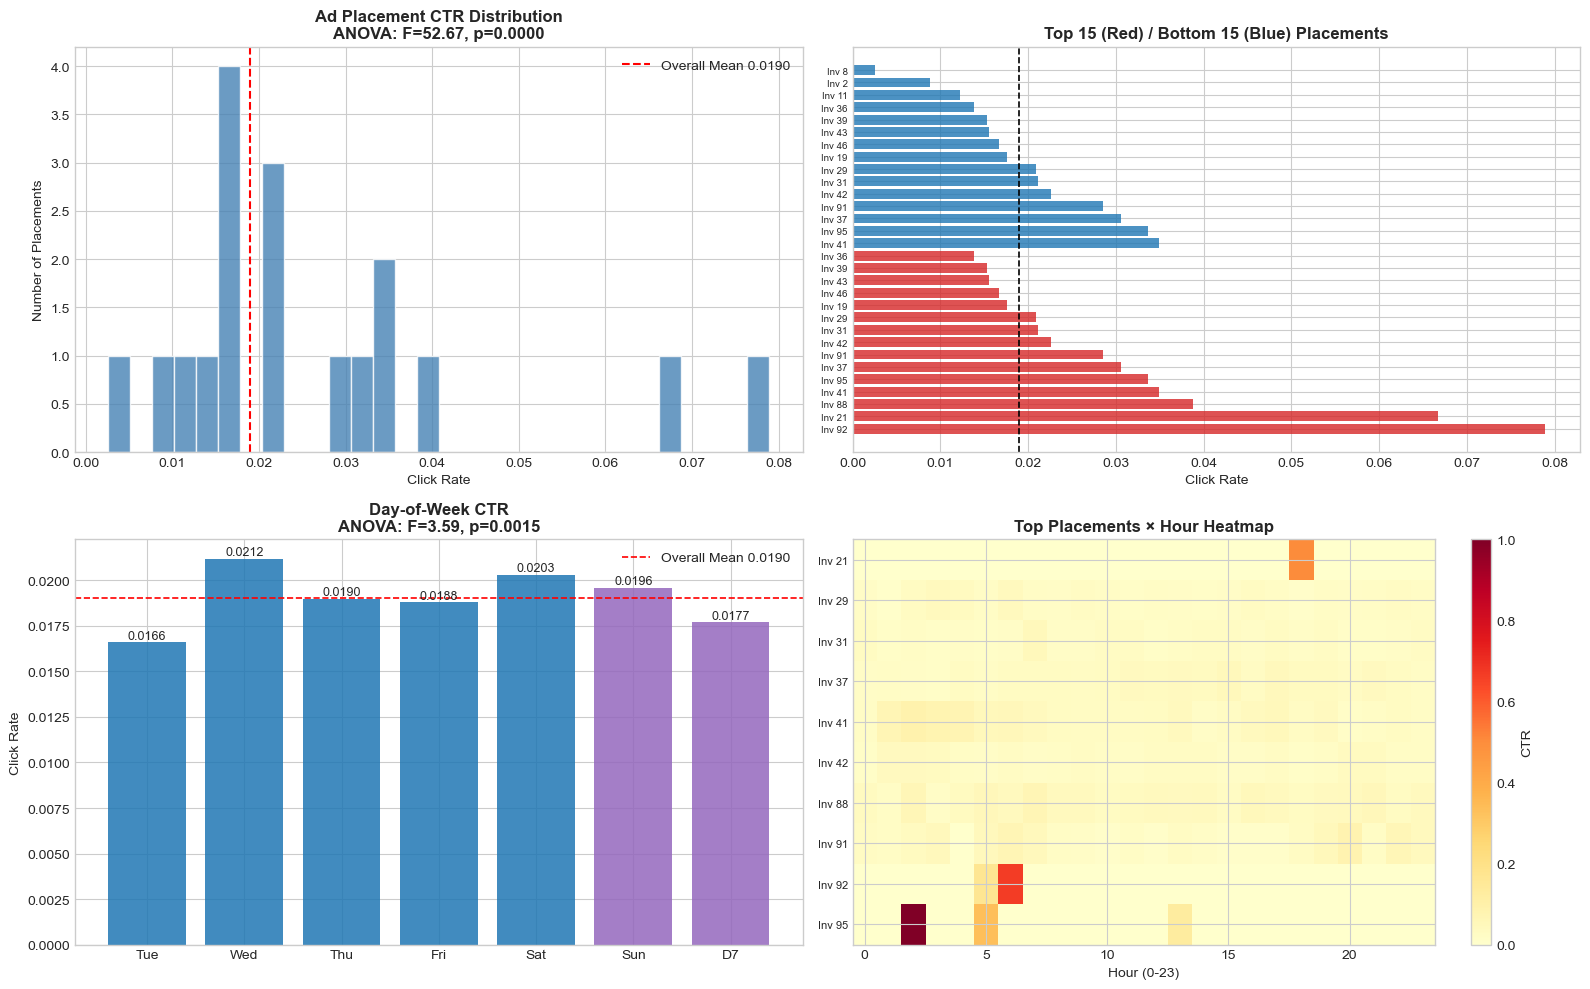

In [ ]:
# ============================================================
# [6] RQ3 — 광고 노출 환경 분석
# ------------------------------------------------------------
# 연구 질문:
#   '광고가 노출되는 인벤토리(지면) 환경에 따라
#    CTR 이 유의미하게 달라지는가?'
#
# 분석 전략:
#   1) 인벤토리별 CTR 기술통계 (최고·최저 지면 확인)
#   2) ANOVA    ─ inventory_id 간 CTR 차이 F-검정
#   3) Chi2     ─ 인벤토리 × 클릭 독립성 (정규성 가정 완화)
#   4) 요일 ANOVA ─ 환경 변수로서 요일 효과 추가 검정
#   5) 시각화   ─ CTR 분포·상위/하위 지면·요일 막대·지면×시간 히트맵
# ============================================================

print_section('RQ3. 광고 노출 환경 분석')

# ── 1) 인벤토리별 CTR 기술통계 ────────────────────────────
inv_desc = df.groupby('inventory_id')['clicked'].agg(
    Sample_Count='count', Click_Rate='mean'
).sort_values('Click_Rate', ascending=False)

print(f'총 광고 지면: {len(inv_desc)}')
print(f'최고 CTR 지면: {inv_desc.index[0]}  ({inv_desc["Click_Rate"].iloc[0]:.4f})')
print(f'최저 CTR 지면: {inv_desc.index[-1]}  ({inv_desc["Click_Rate"].iloc[-1]:.4f})')

# ── 2) ANOVA (인벤토리 간) ────────────────────────────────
# H0: 모든 광고 지면의 모집단 평균 CTR 이 동일하다
inv_groups = [df[df['inventory_id'] == inv]['clicked'].values for inv in df['inventory_id'].unique()]
F_inv, p_inv = f_oneway(*inv_groups)

# ── 3) Chi2 (인벤토리 × 클릭 독립성) ─────────────────────
# ANOVA 정규성 가정 완화 → 비모수 접근으로 결과 강건성 추가 확인
chi2_inv, p_chi2_inv, _, _ = chi2_contingency(pd.crosstab(df['inventory_id'], df['clicked']))

# ── 4) 요일별 CTR + ANOVA ─────────────────────────────────
# 요일을 '광고 노출 환경'의 일부로 보고 RQ3 맥락에서 함께 분석
day_desc       = ctr_desc(df, 'day_of_week')
day_desc.index = [DAY_NAMES[i] if i < 7 else f'D{i}' for i in day_desc.index]
F_dow, p_dow, eta_sq_dow = run_anova_eta(df, 'day_of_week')

print(f'\n[ANOVA inventory] F={F_inv:.2f}, p={p_inv:.6f} {"***" if p_inv<0.001 else ""}')
print(f'[Chi2  inventory] χ²={chi2_inv:.2f}, p={p_chi2_inv:.6f} {"***" if p_chi2_inv<0.001 else ""}')
print(f'[ANOVA day_of_week] F={F_dow:.2f}, p={p_dow:.6f} {"***" if p_dow<0.001 else ""}')
print('\n[요일별 CTR]')
print(day_desc.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# [좌상] 인벤토리 CTR 분포 히스토그램
# 지면별 CTR 이 어떤 분포를 이루는지 전체 관점 파악
axes[0, 0].hist(inv_desc['Click_Rate'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].axvline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.5,
                   label=f'Overall Mean {GLOBAL_CTR:.4f}')
axes[0, 0].set_title(f'Ad Placement CTR Distribution\nANOVA: F={F_inv:.2f}, p={p_inv:.4f}',
                     fontweight='bold')
axes[0, 0].set_xlabel('Click Rate'); axes[0, 0].set_ylabel('Number of Placements')
axes[0, 0].legend()

# [우상] 상위 15 (빨강) / 하위 15 (파랑) 지면 수평 막대
# 광고 집행 우선순위 결정 시 직접 참조 가능한 시각화
top15    = inv_desc.head(15); bot15 = inv_desc.tail(15)
combined = pd.concat([top15, bot15])
colors_inv = ['#d62728']*15 + ['#1f77b4']*15
axes[0, 1].barh(range(len(combined)), combined['Click_Rate'],
                color=colors_inv, alpha=0.8)
axes[0, 1].set_yticks(range(len(combined)))
axes[0, 1].set_yticklabels([f'Inv {i}' for i in combined.index], fontsize=7)
axes[0, 1].axvline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2)
axes[0, 1].set_title('Top 15 (Red) / Bottom 15 (Blue) Placements', fontweight='bold')
axes[0, 1].set_xlabel('Click Rate')

# [좌하] 요일별 CTR 막대 (보라=주말, 파랑=주중)
day_ctrs = day_desc['Click_Rate'].values
colors_d = ['#9467bd' if i >= 5 else '#1f77b4' for i in range(len(day_desc))]
bars = axes[1, 0].bar(day_desc.index, day_ctrs, color=colors_d, alpha=0.85)
axes[1, 0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                   label=f'Overall Mean {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, day_ctrs):
    axes[1, 0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                    f'{v:.4f}', ha='center', fontsize=9)
axes[1, 0].set_title(f'Day-of-Week CTR\nANOVA: F={F_dow:.2f}, p={p_dow:.4f}',
                     fontweight='bold')
axes[1, 0].set_ylabel('Click Rate'); axes[1, 0].legend()

# [우하] 상위 10 지면 × 시간 히트맵
# CTR 상위 지면이 특정 시간대에 더 효율적인지 교차 확인 (RQ2 연계)
top10_inv = inv_desc.head(10).index
pivot_inv = df[df['inventory_id'].isin(top10_inv)].groupby(
    ['inventory_id', 'hour'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1, 1].imshow(pivot_inv.values, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_yticks(range(len(pivot_inv.index)))
axes[1, 1].set_yticklabels([f'Inv {i}' for i in pivot_inv.index], fontsize=8)
axes[1, 1].set_xlabel('Hour (0-23)')
axes[1, 1].set_title('Top Placements × Hour Heatmap', fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label='CTR')

plt.tight_layout()
plt.savefig('RQ3_env_ctr.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================


In [8]:
# ============================================================
# [7] 피처 엔지니어링 + 전처리 (RQ4 모델 학습용)
# ------------------------------------------------------------
# 목적:
#   RQ4 머신러닝 모델에 투입할 피처 집합을 구성하고
#   train / val / test 로 분리한다.
#
# 분할 비율: 6 : 2 : 2  (train : val : test)
#   • stratify=y  → 각 세트의 CTR(클래스 비율) 동일하게 유지
#   • val         → 하이퍼파라미터 튜닝·XGBoost early stopping 기준
#   • test        → 최종 성능 평가 (단 1회 사용 원칙)
#
# 피처 범주:
#   user_feats    ─ 사용자 특성 (성별·연령대)
#   env_feats     ─ 노출 환경 (시간·요일·지면 CTR·주말·피크)
#   history_feats ─ 사용자 이력 집계 (sum/mean/max)
#   seq_feats     ─ 시퀀스 행동 패턴 (길이·다양성·반복성)
#   raw_numeric   ─ 대회 제공 원시 수치 피처 (feat_a~e, l_feat)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 피처 정의 ─────────────────────────────────────────────
user_feats    = ['gender', 'age_group']
env_feats     = ['hour', 'day_of_week', 'inv_ctr_encoded', 'is_weekend', 'is_peak_hour']
history_feats = [c for c in df.columns if c.startswith('history_') and c.endswith(('_sum','_mean','_max'))]
history_feats += ['history_ab_ratio']
seq_feats     = ['seq_length', 'unique_items', 'diversity_ratio', 'repeat_ratio']
# 대회 제공 수치 피처: feat_a~e, l_feat 계열 (수치형만 선택)
raw_numeric   = [c for c in df.columns
                 if any(c.startswith(p) for p in ['feat_a_','feat_b_','feat_c_','feat_d_','feat_e_','l_feat_'])
                 and df[c].dtype in [np.float64, np.int64]]

# 중복 제거 후 실제 존재하는 컬럼만 선택 (없는 피처는 자동 제외)
ALL_FEATURES       = user_feats + env_feats + history_feats + seq_feats + raw_numeric
available_features = [c for c in dict.fromkeys(ALL_FEATURES) if c in df.columns]

X = df[available_features].copy()

# ── 전처리: hour_period Categorical → 정수 변환 ───────────
# sklearn 모델은 Categorical dtype 직접 처리 불가
if 'hour_period' in X.columns:
    period_map = {'심야(0-5)': 0, '오전(6-11)': 1, '오후(12-17)': 2, '저녁(18-23)': 3}
    X['hour_period'] = X['hour_period'].map(period_map).fillna(0).astype(int)

# ── 전처리: object/string → 수치 변환 ────────────────────
for col in X.columns:
    if X[col].dtype.name in ['category', 'object', 'string']:
        X[col] = pd.to_numeric(X[col], errors='coerce')   # 실패 시 NaN

# ── 전처리: 무한대·결측값 처리 ───────────────────────────
# inf → NaN 후 열 중앙값으로 대체 (이상치에 강건한 대체 방법)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True)).fillna(0)
y = df['clicked'].copy()

# ── 데이터 분할: 6 : 2 : 2 ───────────────────────────────
# 1단계: 전체 → train(60%) + temp(40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
# 2단계: temp → val(20%) + test(20%)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print(f'\n피처 수: {len(available_features)}개')
for name, Xs, ys in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    print(f'  {name:5s}: {len(Xs):>10,}  CTR={ys.mean():.4f}')

# ── Logistic Regression 전용 StandardScaler ──────────────
# LR 은 피처 스케일에 민감 → StandardScaler (평균=0, 표준편차=1) 적용.
# fit() 은 X_train 에만, transform() 은 val·test 에 적용
# → train 통계로만 변환하여 데이터 누수(leakage) 방지.
# RF·XGBoost 는 트리 기반으로 스케일 불변 → 원본 사용.
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


# ============================================================



피처 수: 18개
  Train:    120,000  CTR=0.0190
  Val  :     40,000  CTR=0.0190
  Test :     40,000  CTR=0.0190



RQ4. CTR 예측 모델 검증

[1/3] Logistic Regression ...
  Val  LogLoss=0.6538  AUC=0.6623  AP=0.0409
  Test LogLoss=0.6487  AUC=0.7003  (20.3s)

[2/3] Random Forest ...
  Val  LogLoss=0.4577  AUC=0.6817  AP=0.0551
  Test LogLoss=0.4553  AUC=0.7045  (12.0s)

[3/3] XGBoost ...
  Val  LogLoss=0.3500  AUC=0.6549  AP=0.0485
  Test LogLoss=0.3462  AUC=0.6671  (4.6s)

모델                     Val LogLoss  Val AUC Test LogLoss  Test AUC
--------------------------------------------------------------
Logistic Regression         0.6538   0.6623       0.6487    0.7003
Random Forest               0.4577   0.6817       0.4553    0.7045
XGBoost                     0.3500   0.6549       0.3462    0.6671


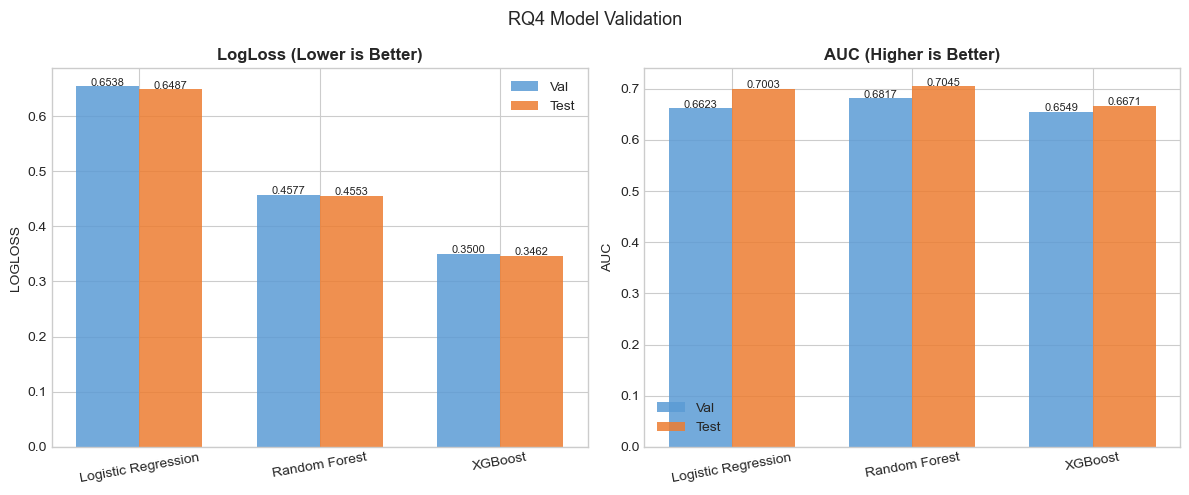

In [ ]:
# ============================================================
# [8] RQ4 — 모델 학습 및 비교 (LR / RF / XGBoost)
# ------------------------------------------------------------
# 연구 질문:
#   '연령·시간·환경 피처를 결합한 모델이
#    피처 단독 사용 대비 CTR 예측력을 향상시키는가?'
#
# 비교 모델:
#   1) Logistic Regression ─ 선형 기준 모델(baseline), 해석 용이
#   2) Random Forest       ─ 비선형 앙상블, 피처 중요도 제공
#   3) XGBoost             ─ 그래디언트 부스팅, 예측 성능 최적화
#
# 평가 지표:
#   Log Loss ─ 확률 보정 품질 (낮을수록 좋음)
#   AUC-ROC  ─ 클래스 구분 능력 (1에 가까울수록 좋음)
#   AP(AUPRC)─ 불균형 데이터 정밀도-재현율 균형 (높을수록 좋음)
#
# 클래스 불균형 처리:
#   LR·RF   ─ class_weight='balanced'
#   XGBoost ─ scale_pos_weight = (비클릭 수) / (클릭 수)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score, average_precision_score
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False   # XGBoost 미설치 환경에서도 LR·RF 는 실행 가능

print_section('RQ4. CTR 예측 모델 검증')

results = {}   # 모델별 평가 지표 저장 딕셔너리

# ── 1) Logistic Regression ──────────────────────────────
# C=1.0     : L2 정규화 강도 (기본값; 작을수록 강한 정규화)
# solver=saga: 대규모 희소 데이터에 적합한 확률적 경사하강법
# max_iter=500: 수렴 보장을 위해 기본값(100)에서 확대
print('\n[1/3] Logistic Regression ...')
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=500, class_weight='balanced',
                        solver='saga', random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train_s, y_train)
for split, Xs, ys in [('val', X_val_s, y_val), ('test', X_test_s, y_test)]:
    p = lr.predict_proba(Xs)[:, 1]   # 클릭 확률 (양성 클래스)
    results.setdefault('Logistic Regression', {}).update({
        f'{split}_logloss': log_loss(ys, p),
        f'{split}_auc':     roc_auc_score(ys, p),
        f'{split}_ap':      average_precision_score(ys, p),
    })
results['Logistic Regression']['time'] = time.time() - t0
r = results['Logistic Regression']
print(f"  Val  LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP={r['val_ap']:.4f}")
print(f"  Test LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# ── 2) Random Forest ────────────────────────────────────
# n_sub=150,000    : 대용량 서브샘플링으로 학습 시간 단축
# n_estimators=200 : 분산 감소를 위한 충분한 트리 수
# max_depth=10     : 깊이 제한으로 과적합 방지
# min_samples_leaf=50: 말단 노드 최소 샘플 (스무딩 효과)
print('\n[2/3] Random Forest ...')
t0    = time.time()
n_sub = min(len(X_train), 150_000)
idx_rf = np.random.choice(len(X_train), n_sub, replace=False)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50,
                             class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train.iloc[idx_rf], y_train.iloc[idx_rf])
for split, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test)]:
    p = rf.predict_proba(Xs)[:, 1]
    results.setdefault('Random Forest', {}).update({
        f'{split}_logloss': log_loss(ys, p),
        f'{split}_auc':     roc_auc_score(ys, p),
        f'{split}_ap':      average_precision_score(ys, p),
    })
results['Random Forest']['time'] = time.time() - t0
r = results['Random Forest']
print(f"  Val  LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP={r['val_ap']:.4f}")
print(f"  Test LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# ── 3) XGBoost ──────────────────────────────────────────
# early_stopping_rounds=20: val logloss 가 20라운드 개선 없으면 조기 종료
#   → 과적합 방지 + 최적 n_estimators 자동 결정
# scale_pos_weight: 불균형 보정 = (비클릭 수) / (클릭 수)
# subsample·colsample_bytree: 배깅·피처 서브샘플링으로 과적합 억제
if HAS_XGB:
    print('\n[3/3] XGBoost ...')
    t0  = time.time()
    spw = (y_train == 0).sum() / (y_train == 1).sum()   # 클래스 가중치 비율
    xgb_model = XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='logloss',
        early_stopping_rounds=20, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    for split, Xs, ys in [('val', X_val, y_val), ('test', X_test, y_test)]:
        p = xgb_model.predict_proba(Xs)[:, 1]
        results.setdefault('XGBoost', {}).update({
            f'{split}_logloss': log_loss(ys, p),
            f'{split}_auc':     roc_auc_score(ys, p),
            f'{split}_ap':      average_precision_score(ys, p),
        })
    results['XGBoost']['time'] = time.time() - t0
    r = results['XGBoost']
    print(f"  Val  LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP={r['val_ap']:.4f}")
    print(f"  Test LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# ── 모델 비교 결과표 출력 ────────────────────────────────
print('\n' + '='*62)
print(f'{"모델":<22} {"Val LogLoss":>11} {"Val AUC":>8} {"Test LogLoss":>12} {"Test AUC":>9}')
print('-'*62)
for name, r in results.items():
    print(f"{name:<22} {r['val_logloss']:>11.4f} {r['val_auc']:>8.4f} "
          f"{r['test_logloss']:>12.4f} {r['test_auc']:>9.4f}")
print('='*62)

# ── 성능 시각화: Val vs Test 비교 ───────────────────────
# Val·Test 성능 일치 여부 → 과적합·일반화 능력 진단
models = list(results.keys())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(models)); w = 0.35

for ax, metric, ylabel in [
    (axes[0], 'logloss', 'LogLoss (Lower is Better)'),
    (axes[1], 'auc',     'AUC (Higher is Better)'),
]:
    val_vals  = [results[m][f'val_{metric}']  for m in models]
    test_vals = [results[m][f'test_{metric}'] for m in models]
    ax.bar(x - w/2, val_vals,  w, label='Val',  color='#5B9BD5', alpha=0.85)
    ax.bar(x + w/2, test_vals, w, label='Test', color='#ED7D31', alpha=0.85)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=10)
    ax.legend(); ax.set_ylabel(metric.upper())
    for i, (v, t) in enumerate(zip(val_vals, test_vals)):
        ax.text(i - w/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)
        ax.text(i + w/2, t + 0.001, f'{t:.4f}', ha='center', fontsize=8)

plt.suptitle('RQ4 Model Validation', fontsize=13)
plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================



Ablation Study — Feature Subset 비교 (3-Fold CV)
  [User only   ] n=   2  AP=0.0230±0.0001  AUC=0.5500±0.0042
  [Env only    ] n=   5  AP=0.0294±0.0001  AUC=0.6194±0.0024
  [User + Env  ] n=   7  AP=0.0354±0.0012  AUC=0.6376±0.0020
  [Full        ] n=  18  AP=0.0581±0.0015  AUC=0.6985±0.0008


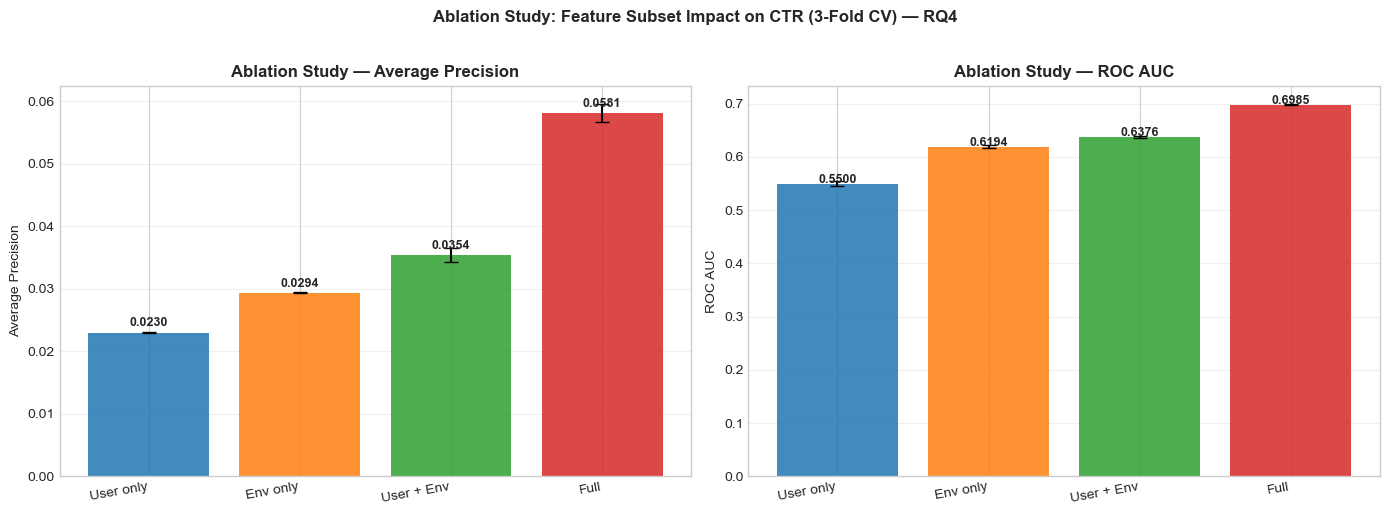

In [ ]:
# ============================================================
# [9] XGBoost Ablation Study (피처 서브셋 비교)
# ------------------------------------------------------------
# 목적:
#   사용자 피처(User)·환경 피처(Env) 가 각각·결합하여
#   CTR 예측에 기여하는 정도를 정량적으로 분리 측정.
#   → RQ4 '피처 결합의 예측력 향상' 가설 검증
#
# 실험 설계: 4개 피처 서브셋 × 3-Fold StratifiedKFold CV
#   User only  ─ 성별·연령대만
#   Env only   ─ 시간·요일·지면 CTR·주말·피크만
#   User+Env   ─ 위 두 범주 결합
#   Full       ─ 모든 피처 (history·seq·raw_numeric 포함)
#
# 교차검증 이유:
#   단일 train/val 분할보다 결과 변동성 낮음 → 피처 기여도
#   추정 신뢰성 향상 (평균 ± 표준편차로 보고)
# ============================================================

if HAS_XGB:
    from sklearn.model_selection import StratifiedKFold

    print_section('Ablation Study — Feature Subset 비교 (3-Fold CV)')

    # 피처 서브셋 정의
    user_cols = [c for c in X.columns if any(c.startswith(f) for f in ['gender','age_group'])]
    env_cols  = [c for c in X.columns if any(c.startswith(f) for f in ['hour','day_of_week','inv_ctr','is_'])]
    all_cols  = list(X.columns)

    subsets = {
        'User only':    user_cols,
        'Env only':     env_cols,
        'User + Env':   list(dict.fromkeys(user_cols + env_cols)),  # 순서 보존 중복 제거
        'Full':         all_cols,
    }

    # StratifiedKFold: 각 fold 에서 CTR 비율 동일하게 유지
    cv_abl   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    abl_rows = []

    for label, cols in subsets.items():
        valid_cols = [c for c in cols if c in X.columns]
        if not valid_cols:
            continue
        X_sub = X[valid_cols]
        ap_folds, auc_folds = [], []
        for tr_i, va_i in cv_abl.split(X_sub, y):
            Xtr, Xva = X_sub.iloc[tr_i], X_sub.iloc[va_i]
            ytr, yva = y.iloc[tr_i],     y.iloc[va_i]
            clf = XGBClassifier(
                n_estimators=200, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=(ytr==0).sum()/(ytr==1).sum(),  # fold별 불균형 비율 재계산
                random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
            )
            # fold 내 train 평균으로 결측값 대체 → val 정보 누수 방지
            clf.fit(Xtr.fillna(Xtr.mean()), ytr)
            prob = clf.predict_proba(Xva.fillna(Xtr.mean()))[:, 1]
            ap_folds.append(average_precision_score(yva, prob))
            auc_folds.append(roc_auc_score(yva, prob))
        abl_rows.append({
            'Feature Set': label, 'n_features': len(valid_cols),
            'AP': np.mean(ap_folds), 'AP_std': np.std(ap_folds),
            'AUC': np.mean(auc_folds), 'AUC_std': np.std(auc_folds),
        })
        print(f'  [{label:12s}] n={len(valid_cols):4d}  AP={np.mean(ap_folds):.4f}±{np.std(ap_folds):.4f}  '
              f'AUC={np.mean(auc_folds):.4f}±{np.std(auc_folds):.4f}')

    abl_df = pd.DataFrame(abl_rows)

    # ── Ablation 시각화: AP / AUC × 피처 서브셋 ──────────
    # 에러바(표준편차) → 결과 안정성 직관적 파악
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_abl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for ax, metric, std_col, ylabel in [
        (axes[0], 'AP',  'AP_std',  'Average Precision'),
        (axes[1], 'AUC', 'AUC_std', 'ROC AUC'),
    ]:
        bars = ax.bar(range(len(abl_df)), abl_df[metric],
                      yerr=abl_df[std_col], color=colors_abl[:len(abl_df)], alpha=0.85, capsize=5)
        ax.set_xticks(range(len(abl_df)))
        ax.set_xticklabels(abl_df['Feature Set'], rotation=10, ha='right')
        ax.set_ylabel(ylabel); ax.set_title(f'Ablation Study — {ylabel}', fontweight='bold')
        for bar, v in zip(bars, abl_df[metric]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                    f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Ablation Study: Feature Subset Impact on CTR (3-Fold CV) — RQ4',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================



SHAP 분석 중...


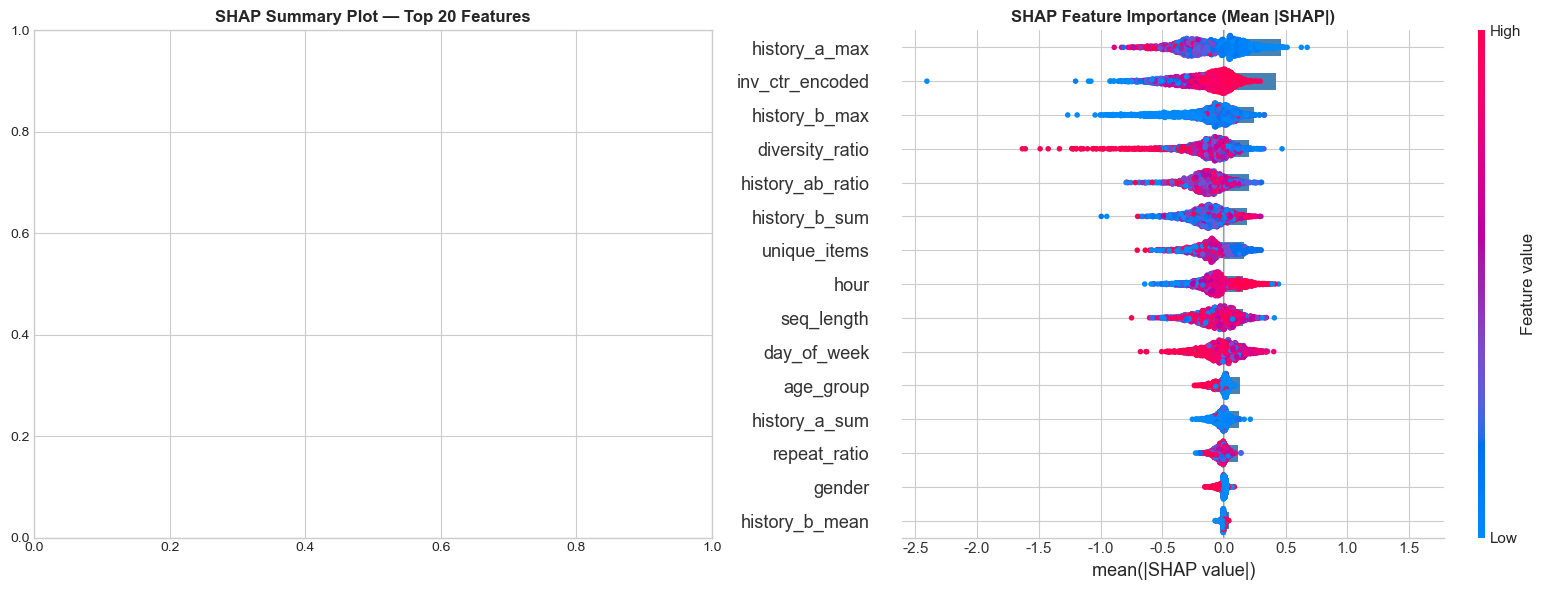


Top 10 SHAP features:
                  mean_abs_shap
history_a_max          0.459552
inv_ctr_encoded        0.420702
history_b_max          0.244094
diversity_ratio        0.206807
history_ab_ratio       0.200746
history_b_sum          0.185750
unique_items           0.163413
hour                   0.153295
seq_length             0.152636
day_of_week            0.140618


In [ ]:
# ============================================================
# [10] SHAP 해석 (XGBoost 기준 — 모델 설명 가능성)
# ------------------------------------------------------------
# 목적:
#   XGBoost 모델이 어떤 피처를 근거로 클릭을 예측하는지
#   SHAP(SHapley Additive exPlanations) 값으로 정량 해석한다.
#
# SHAP 원리:
#   협력 게임이론 Shapley 값에서 유래.
#   각 피처의 예측 기여도를 방향(+/-)과 크기로 분해 →
#   전역(global)·개별(local) 수준 해석 모두 가능.
#
# 시각화:
#   Summary Plot (dot): 피처별 SHAP 분포 + 피처값 색상 인코딩
#     빨강 = 피처값 높음, 파랑 = 낮음
#     → 고값일 때 CTR 에 긍정·부정 영향 여부 직독
#   Feature Importance Bar: 평균 |SHAP| 기준 상위 15 피처 순위
# ============================================================

if HAS_XGB:
    try:
        import shap
        print('\nSHAP 분석 중...')

        # val 세트에서 최대 2,000개 무작위 샘플 (속도·메모리 절충)
        rng_shap = np.random.default_rng(RANDOM_STATE)
        shap_idx = rng_shap.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
        X_shap   = X_val.iloc[shap_idx]

        # TreeExplainer: 트리 기반 모델 전용 → 정확한 exact 계산 지원
        explainer = shap.TreeExplainer(xgb_model)
        shap_vals = explainer.shap_values(X_shap)
        # 이진 분류에서 list 반환 시 양성 클래스(클릭=1) SHAP 선택
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        # 전역 피처 중요도: 평균 절대 SHAP 값
        shap_importance = (
            pd.Series(np.abs(shap_vals).mean(axis=0), index=X_shap.columns)
            .sort_values(ascending=False)
        )

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # ── 왼쪽: SHAP Summary Plot ────────────────────────
        # 각 점 = 1개 샘플, x축 = SHAP 값, 색상 = 피처 원래 값
        shap.summary_plot(shap_vals, X_shap, max_display=20, show=False, plot_type='dot',
                          plot_size=None)
        plt.sca(axes[0])
        axes[0].set_title('SHAP Summary Plot — Top 20 Features', fontweight='bold')

        # ── 오른쪽: 평균 |SHAP| 막대 (논문 피처 중요도 표 대용)
        shap_importance.head(15).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
        axes[1].set_title('SHAP Feature Importance (Mean |SHAP|)', fontweight='bold')
        axes[1].set_xlabel('mean(|SHAP value|)')

        plt.tight_layout()
        plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('\nTop 10 SHAP features:')
        print(shap_importance.head(10).to_frame('mean_abs_shap'))
    except ImportError:
        print('SHAP 미설치: pip install shap')


# ============================================================


In [12]:
# ============================================================
# [11] 추론 및 제출 파일 생성
# ------------------------------------------------------------
# 목적:
#   최종 선택 모델(XGBoost) 로 test 데이터를 예측하고
#   대회 제출 형식(sample_submission)에 맞춰 CSV 로 저장한다.
#
# 주요 처리:
#   • test 에 없는 학습 피처 컬럼 → 0 으로 패딩 (shape 통일)
#   • float32 캐스팅 → 메모리 50% 절감 (float64 대비)
#   • predict_proba(...)[:, 1] → 클릭 확률 (0~1) 출력
# ============================================================

if test is not None and HAS_XGB:
    print('\n추론 시작...')

    # test 에서 학습 피처만 추출 (없는 컬럼은 아래서 0 보완)
    X_test_final = (
        test[[c for c in available_features if c in test.columns]]
        .apply(pd.to_numeric, errors='coerce')   # 문자열 컬럼 수치 변환
        .fillna(0)                                # 결측값 0 대체
        .astype(np.float32)                       # 메모리 절감
    )
    # 학습 시 사용했지만 test 에 없는 컬럼 → 0 으로 추가
    for c in available_features:
        if c not in X_test_final.columns:
            X_test_final[c] = 0
    X_test_final = X_test_final[available_features]   # 컬럼 순서를 학습 시와 동일하게 정렬

    test_preds = xgb_model.predict_proba(X_test_final)[:, 1]

    if sample is not None:
        submission = sample.copy()
        submission['clicked'] = test_preds
        out_path = BASE_DIR / 'notebooks' / 'submission_xgb.csv'
        out_path.parent.mkdir(parents=True, exist_ok=True)
        submission.to_csv(out_path, index=False)
        print(f'제출 파일 저장: {out_path}')
        print(f'예측 평균 CTR: {test_preds.mean():.6f}')
        print(submission.head())
    else:
        print('sample_submission.csv 없음 — 예측값만 생성됨')
        print(f'test_preds shape: {test_preds.shape}, mean: {test_preds.mean():.6f}')


# ============================================================



추론 시작...
제출 파일 저장: c:\statistical_ctr_analysis\notebooks\submission_xgb.csv
예측 평균 CTR: 0.048112
             ID   clicked
0  TEST_0000000  0.031732
1  TEST_0000001  0.059183
2  TEST_0000002  0.063592
3  TEST_0000003  0.041955
4  TEST_0000004  0.032990


In [ ]:
# ============================================================
# [12] 논문용 최종 결론 요약
# ------------------------------------------------------------
# 목적:
#   RQ1~RQ4 의 통계 검정 결과를 자동 취합하여
#   논문 결론 절에 바로 활용 가능한 형태로 출력한다.
#
# 해석 기준:
#   p < 0.001            → 통계적으로 매우 유의 (***)
#   eta2 < 0.06          → 작은 효과 / 0.06~0.14 → 중간 / >=0.14 → 큰 효과
#   Combined AP > max(User AP, Env AP) → 피처 결합 효과 입증
# ============================================================

print_section('연구 결론 요약')

# ── RQ1: 연령대 효과 ──────────────────────────────────────
print(f'RQ1 — 연령대별 CTR: ANOVA F={F_age:.2f}, p={p_anova_age:.6f}, eta2={eta_sq_age:.4f}')
print(f'      => {"유의미한 차이 존재 (p<0.001)" if p_anova_age<0.001 else "유의하지 않음"}')
print(f'      => 효과 크기: {"작음 — 실질적 영향 제한적" if eta_sq_age<0.06 else "중간" if eta_sq_age<0.14 else "큼"}')

# ── RQ2: 시간대 효과 ──────────────────────────────────────
print(f'\nRQ2 — 시간대별 CTR: ANOVA F={F_hour:.2f}, p={p_hour:.6f}, eta2={eta_sq_hour:.4f}')
print(f'      => {"유의미한 시간 효과 존재" if p_hour<0.001 else "유의하지 않음"}')

# ── RQ3: 광고 노출 환경 효과 ──────────────────────────────
print(f'\nRQ3 — 광고 지면 CTR: ANOVA F={F_inv:.2f}, p={p_inv:.6f}')
print(f'      => {"광고 지면 간 유의미한 CTR 차이 존재" if p_inv<0.001 else "유의하지 않음"}')
print(f'      요일 효과: ANOVA F={F_dow:.2f}, p={p_dow:.6f} {"(유의)" if p_dow<0.001 else "(비유의)"}')

# ── RQ4: 피처 결합 효과 (Ablation 결과 기반) ──────────────
if 'abl_df' in dir() and len(abl_df) >= 3:
    u_ap = abl_df.loc[abl_df['Feature Set']=='User only',  'AP'].values[0]
    e_ap = abl_df.loc[abl_df['Feature Set']=='Env only',   'AP'].values[0]
    c_ap = abl_df.loc[abl_df['Feature Set']=='User + Env', 'AP'].values[0]
    print(f'\nRQ4 — 피처 결합 효과: User AP={u_ap:.4f}, Env AP={e_ap:.4f}, Combined AP={c_ap:.4f}')
    print(f'      => {"사용자+환경 결합이 CTR 예측 향상 확인" if c_ap>max(u_ap,e_ap) else "단일 그룹보다 개선 없음"}')

# ── 연구 기여 요약 ────────────────────────────────────────
print('\n본 연구의 기여:')
print('  CTR 이 왜 달라지는지를 통계적으로 설명하고 모델로 재검증하여')
print('  실무 의사결정(타겟팅·노출 시간 최적화)으로 연결한 데 있다.')


# ============================================================



연구 결론 요약
RQ1 — 연령대별 CTR: ANOVA F=37.12, p=0.000000, eta2=0.0013
      => 유의미한 차이 존재 (p<0.001)
      => 효과 크기: 작음 — 실질적 영향 제한적

RQ2 — 시간대별 CTR: ANOVA F=2.51, p=0.000078, eta2=0.0003
      => 유의미한 시간 효과 존재

RQ3 — 광고 지면 CTR: ANOVA F=52.67, p=0.000000
      => 광고 지면 간 유의미한 CTR 차이 존재
      요일 효과: ANOVA F=3.59, p=0.001468 (비유의)

RQ4 — 피처 결합 효과: User AP=0.0230, Env AP=0.0294, Combined AP=0.0354
      => 사용자+환경 결합이 CTR 예측 향상 확인

본 연구의 기여:
  CTR이 왜 달라지는지를 통계적으로 설명하고 모델로 재검증하여
  실무 의사결정(타겟팅/노출 시간 최적화)으로 연결한 데 있다.
